# Single cell reference (PBMC3K)

Preprocess and annotate PBMC3K.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
import matplotlib.pyplot as plt
import seaborn as sns

from dtangle import deconvolut

In [2]:
adata = sc.datasets.pbmc3k()
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

In [3]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata, resolution=0.2, key_added="leiden")
sc.tl.umap(adata)

/tmp/ipykernel_10289/3177813798.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.2, key_added="leiden")


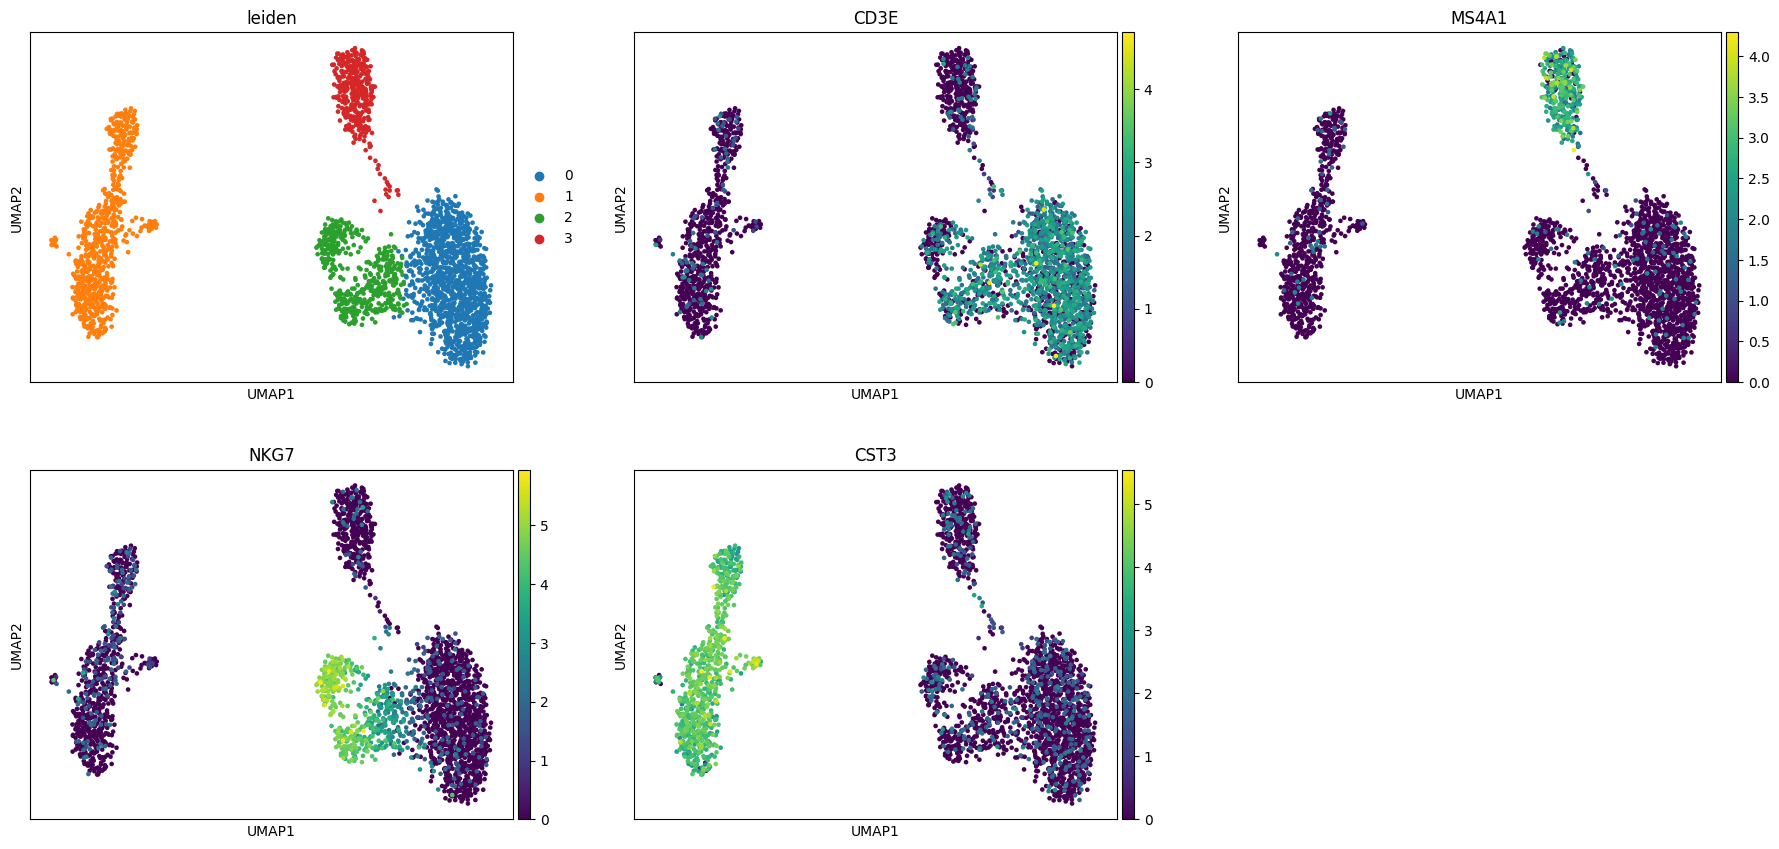

In [4]:
sc.pl.umap(
    adata,
    color=[
        "leiden",
        "CD3E",
        "MS4A1",
        "NKG7",
        "CST3",
    ],
    ncols=3,
)

In [5]:
adata.obs["celltype"] = adata.obs["leiden"].map(
    {
        "0": "T cells",
        "1": "Monocytes",
        "2": "NK cells",
        "3": "B cells",
    }
)

<Axes: title={'center': 'celltype'}, xlabel='UMAP1', ylabel='UMAP2'>

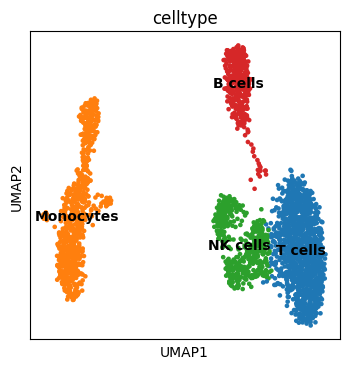

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(adata, color=["celltype"], legend_loc="on data", ax=ax, show=False)

Build pseudobulk AnnData

In [7]:
rng = np.random.default_rng(42)
donors = [f"donor_{i}" for i in range(8)]
adata.obs["donor"] = rng.choice(donors, size=adata.n_obs, replace=True)
truth = pd.crosstab(adata.obs["donor"], adata.obs["celltype"], normalize="index")
truth = truth.reindex(donors, fill_value=0.0)
counts = adata.layers["counts"]
pb_rows = []
for d in donors:
    idx = np.where(adata.obs["donor"].to_numpy() == d)[0]
    pb_rows.append(np.asarray(counts[idx].sum(axis=0)).ravel())

# Create pseudo-bulk dataset
pb = AnnData(X=np.vstack(pb_rows))
pb.obs_names = donors
pb.var_names = adata.var_names.copy()
pb.obsm["ground_truth"] = truth.copy()
sc.pp.log1p(pb)

# Create reference dataset
reference = AnnData(X=adata.layers["counts"].copy(), obs=adata.obs[["celltype"]].copy())
reference.var_names = adata.var_names.copy()
sc.pp.log1p(reference)

Deconvolution and comparison

In [8]:
deconvolut(
    pb,
    reference,
    "celltype",
    n_markers=30,
    marker_method="ratio",
    data_type="rna-seq",
    key_added="dtangle",
)

In [9]:
est = pb.obsm["dtangle"].copy()
truth_aligned = pb.obsm["ground_truth"].reindex(columns=est.columns, fill_value=0.0)
mae_by_type = (est - truth_aligned).abs().mean(axis=0).sort_values()
overall_mae = float((est - truth_aligned).abs().to_numpy().mean())
comparison = est.add_prefix("est_").join(truth_aligned.add_prefix("truth_"))
print(f"overall_mae: {overall_mae:.4f}")

overall_mae: 0.0226


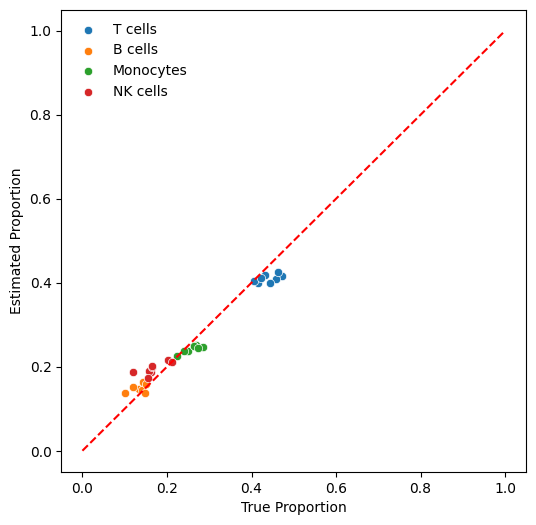

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
for ct in est.columns:
    sns.scatterplot(
        x=comparison[f"truth_{ct}"],
        y=comparison[f"est_{ct}"],
        ax=ax,
        label=ct,
    )
ax.plot([0, 1], [0, 1], "r--")
ax.set_xlabel("True Proportion")
ax.set_ylabel("Estimated Proportion")
_ = ax.legend(frameon=False)